# MIMIC OOD Multi-Seed (Low-Rank Gaussian, weighted)

One model evaluated across multiple random seeds:

- Model: Low-Rank Gaussian (r=15)
- Training: weighted (class weights enabled)
- ID: ICU test
- OOD: Newborn
- Metrics: `MI`, `EU_var`, `sum_Ck`, `C1`, `neg_MSP`

Outputs: per-seed checkpoints, per-seed metrics CSV, aggregated mean±std CSV.

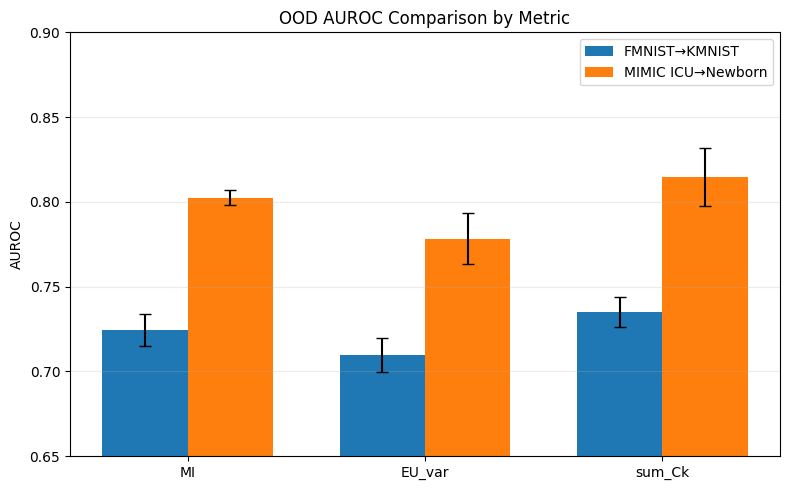

Saved: figs/bar_auroc_fmnist_vs_mimic.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

fmnist_csv = "results_csv/fmnist_kmnist_lowrank_gauss_multiseed_agg.csv"
mimic_csv  = "results_csv/mimic_lowrank_gauss_multiseed_agg.csv"

fmnist = pd.read_csv(fmnist_csv)
mimic = pd.read_csv(mimic_csv)

# Select metrics
metrics = ["MI", "EU_var", "sum_Ck"]
fmnist = fmnist.set_index("metric").loc[metrics]
mimic  = mimic.set_index("metric").loc[metrics]

fmnist_mean = fmnist["AUROC_mean"].values
fmnist_std  = fmnist["AUROC_std"].values
mimic_mean  = mimic["AUROC_mean"].values
mimic_std   = mimic["AUROC_std"].values

x = np.arange(len(metrics))
w = 0.36

plt.figure(figsize=(8,5))
plt.bar(x - w/2, fmnist_mean, w, yerr=fmnist_std, capsize=4, label="FMNIST→KMNIST")
plt.bar(x + w/2, mimic_mean,  w, yerr=mimic_std,  capsize=4, label="MIMIC ICU→Newborn")

plt.xticks(x, metrics)
plt.ylabel("AUROC")
plt.ylim(0.65, 0.90)
plt.title("OOD AUROC Comparison by Metric")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

out = "figs/bar_auroc_fmnist_vs_mimic.png"
plt.savefig(out, dpi=300)
plt.show()
print("Saved:", out)